# Corporate Wallet Digital Twin V3.1 - executed judging notebook

**Team:** Corporate Wallet Digital Twin  
**Member:** Christopher Koen  
**Snapshot:** 30 June 2026  
**Build:** 12 August 2026

The notebook reproduces the Corporate Banking Decision Twin: 20 twelve-component Business Twins, 320 client-solution estimates, the eight-conversation weekly plan, a BHP explanation path, dual value, funding-route intelligence and the reviewed value-of-information answer loop.

> **Claim boundary:** Syn Bank activity is simulated; public facts are E1; representative policies and E0 claims demonstrate mechanics. Competitor share is not measured, bank economics are not approved, feasibility remains unknown where bank systems are absent, and causal incremental value is withheld.

In [1]:
from pathlib import Path
import json, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / 'src').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
from wallet_twin_v31.repository import repository

print(repository.metadata['title'])
print(repository.metadata['watermark'])
print('Bank production:', repository.release['bank_production_status'])

Corporate Wallet Digital Twin V3.1
CLIENT DEMONSTRATION — AUDITED PUBLIC E1 FACTS + SYN BANK SIMULATION + REPRESENTATIVE POLICY — UNKNOWN INPUTS REMAIN UNKNOWN
Bank production: NOT_PROMOTABLE


## 1. Reproduce the governed V3.1 snapshot

In [2]:
summary = pd.Series(repository.validation, name='value')
display(summary.loc[[
    'clients','business_twin_components','business_evidence_claims','business_evidence_gaps',
    'graph_nodes','graph_edges','problem_hypotheses','identified_problems',
    'solution_projections','available_solution_estimates','fail_closed_solution_estimates',
    'conversation_candidates','coverage_plan_size','voi_questions_evaluated','voi_questions_selected'
]].to_frame())
assert repository.validation['clients'] == 20
assert repository.validation['business_twin_components'] == 240
assert repository.validation['solution_projections'] == 320
assert repository.validation['coverage_plan_size'] == 8
assert repository.validation['coverage_solver_status'] == 'OPTIMAL'

,value
clients,20
business_twin_components,240
business_evidence_claims,905
business_evidence_gaps,71
graph_nodes,993
graph_edges,1154
problem_hypotheses,360
identified_problems,224
solution_projections,320
available_solution_estimates,198


## 2. Twenty Business Model Twins and evidence completeness

In [3]:
twin_rows = []
for entity_id, twin in repository.twins.items():
    coverage = repository.evidence_coverage['per_client'][entity_id]
    twin_rows.append({
        'client': twin.entity_name, 'sector': twin.sector, 'components': len(twin.components),
        'typed_claims': twin.claim_count, 'approved_claims': twin.approved_claim_count,
        'domains': twin.supported_domain_count, 'E1_approved': coverage['e1_approved_claims'],
        'gaps': len(twin.evidence_gaps), 'meets_15_E1_target': coverage['meets_e1_threshold'],
    })
twins = pd.DataFrame(twin_rows).sort_values('client')
display(twins)
assert (twins['components'] == 12).all()
assert (twins['typed_claims'] >= 15).all()
assert (twins['domains'] >= 9).all()
assert not twins['meets_15_E1_target'].any()
display(Markdown('**Open gate:** the real audited estate does not support 15 reviewed E1 claims per client. No fact has been invented to close it.'))

,client,sector,components,typed_claims,approved_claims,domains,E1_approved,gaps,meets_15_E1_target
2,Anglo American,mining,12,44,41,11,0,4,False
3,AngloGold Ashanti,mining,12,44,41,11,0,4,False
18,Aspen Pharmacare,industrials_pharma,12,44,41,11,0,4,False
0,BHP Group,mining,12,52,52,11,11,1,False
9,Bid Corporation,consumer,12,44,41,11,0,4,False
11,Clicks Group,consumer,12,44,41,11,0,4,False
1,Glencore,mining,12,52,52,11,11,1,False
4,Gold Fields,mining,12,44,41,11,0,4,False
15,MTN Group,telecoms,12,44,41,11,0,4,False
12,NEPI Rockcastle,real_estate,12,44,41,11,0,4,False


**Open gate:** the real audited estate does not support 15 reviewed E1 claims per client. No fact has been invented to close it.

## 3. All sixteen solutions across all twenty clients

In [4]:
estimate_rows = []
for entity_id, estimates in repository.estimates.items():
    client = repository.twins[entity_id].entity_name
    for solution, estimate in estimates.items():
        estimate_rows.append({
            'client': client, 'solution': solution.value, 'status': 'AVAILABLE' if estimate.available else 'FAIL_CLOSED',
            'claim_class': estimate.claim_class.value, 'calibration': estimate.calibration_status,
            'reason_count': int(estimate.unavailable_reason is not None),
        })
estimates = pd.DataFrame(estimate_rows)
display(pd.crosstab(estimates['solution'], estimates['status']))
assert len(estimates) == 320
assert len(estimates['solution'].unique()) == 16
assert (estimates.groupby('client').size() == 16).all()

status,AVAILABLE,FAIL_CLOSED
solution,,
COLLECTIONS,20,0
COMMODITY_RISK_MANAGEMENT,6,14
CROSS_BORDER_FX,20,0
DEBT_CAPITAL_MARKETS,16,4
ESCROW_AND_AGENCY,0,20
GUARANTEES_AND_LC,20,0
INTEREST_RATE_RISK_MANAGEMENT,18,2
LIQUIDITY_CASH_MANAGEMENT,20,0
MA_AND_STRATEGIC_ADVISORY,0,20


## 4. Eight-conversation Pareto and CVaR weekly plan

In [5]:
plan = pd.DataFrame([entry.model_dump(mode='json') for entry in repository.plan.entries])
display(plan[['rank','entity_name','stakeholder_role','problem_label','solution_label',
              'client_value_median','bank_value_median','selection_stability','action','eligibility']])
print('Solver:', repository.plan.solver_status, '| degraded fallback:', repository.plan.degraded_fallback)
print('Constraint report:', json.dumps(repository.plan.constraint_report, indent=2))
assert len(plan) == 8
assert repository.plan.solver_status == 'OPTIMAL'
assert not repository.plan.degraded_fallback
assert set(plan['action']) == {'DISCOVERY'}

,rank,entity_name,stakeholder_role,problem_label,solution_label,client_value_median,bank_value_median,selection_stability,action,eligibility
0,1,Bid Corporation,TREASURER,Liquidity fragmentation,Liquidity and cash management,1.369997e+07,3.990240e+06,0.7917,DISCOVERY,DISCOVERY_ONLY
1,2,Sanlam,FINANCE_OPERATIONS,Payments inefficiency,Payments,1.704380e+07,3.842587e+06,0.6250,DISCOVERY,DISCOVERY_ONLY
2,3,Sanlam,TREASURER,Liquidity fragmentation,Liquidity and cash management,1.704380e+07,3.842587e+06,0.2917,DISCOVERY,DISCOVERY_ONLY
3,4,BHP Group,TREASURER,FX exposure,Cross-border FX,1.464448e+07,8.059727e+06,0.3333,DISCOVERY,DISCOVERY_ONLY
4,5,Shoprite Holdings,TREASURER,FX exposure,Cross-border FX,5.864010e+06,4.161504e+05,1.0000,DISCOVERY,DISCOVERY_ONLY
5,6,MTN Group,TREASURER,FX exposure,Cross-border FX,1.187114e+07,8.370638e+06,1.0000,DISCOVERY,DISCOVERY_ONLY
6,7,BHP Group,COO,Supply-chain risk,Trade finance,7.907087e+09,1.145482e+07,0.7917,DISCOVERY,DISCOVERY_ONLY
7,8,Shoprite Holdings,COO,Supply-chain risk,Trade finance,2.619986e+09,1.539017e+06,1.0000,DISCOVERY,DISCOVERY_ONLY


Solver: OPTIMAL | degraded fallback: False
Constraint report: {
  "per_client": {
    "E10": 1,
    "E08": 2,
    "E01": 2,
    "E09": 2,
    "E16": 1
  },
  "per_client_role": {
    "E10|TREASURER": 1,
    "E08|FINANCE_OPERATIONS": 1,
    "E08|TREASURER": 1,
    "E01|TREASURER": 1,
    "E09|TREASURER": 1,
    "E16|TREASURER": 1,
    "E01|COO": 1,
    "E09|COO": 1
  },
  "per_solution_family": {
    "TRANSACTION_BANKING": 3,
    "RISK_MANAGEMENT": 3,
    "TRADE_AND_WORKING_CAPITAL": 2
  },
  "per_sector": {
    "consumer": 3,
    "insurance": 2,
    "mining": 2,
    "telecoms": 1
  }
}


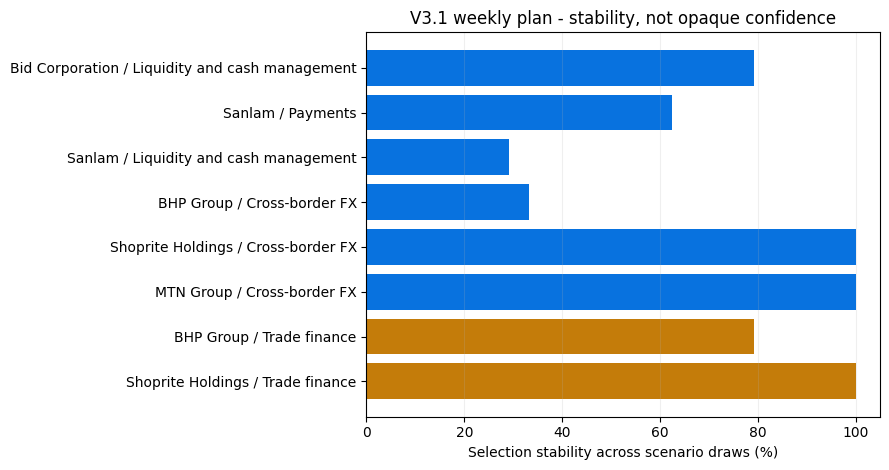

In [6]:
fig, ax = plt.subplots(figsize=(9,4.8))
colors = ['#0872df' if x != 'TRADE_FINANCE' else '#c47c0a' for x in plan['primary_solution']]
ax.barh(plan['entity_name'] + ' / ' + plan['solution_label'], plan['selection_stability'] * 100, color=colors)
ax.invert_yaxis(); ax.set_xlabel('Selection stability across scenario draws (%)')
ax.set_title('V3.1 weekly plan - stability, not opaque confidence')
ax.grid(axis='x', alpha=.2); plt.tight_layout(); plt.show()

## 5. BHP explanation path and separated value

In [7]:
bhp_entry = next(entry for entry in repository.plan.entries if entry.entity_name == 'BHP Group')
bhp = repository.conversation(bhp_entry.conversation_id, repository.as_of)
path = bhp.explanation_path
display(Markdown(f'''### {bhp.entity_name} - {bhp.problem.label}

**Stakeholder:** {bhp.stakeholder.primary_role.value}  
**Solution:** {bhp.solution_bundle.primary.value}  
**Path:** `Event -> Business impact -> Problem -> Stakeholder -> Solution -> Client value -> Bank value`  
**Why now:** {bhp.engagement_window.why_now}
'''))
print('Client value:', bhp.client_value.monetised_total)
print('Bank direct contribution:', bhp.bank_value.direct_contribution)
print('Three-year relationship scenario:', bhp.bank_value.relationship_value_3y)
print('Causal value:', bhp.bank_value.causal_incremental_value)
print('Evidence claims in path:', len({claim_id for step in path.steps for claim_id in step.evidence_claim_ids}))
assert bhp.bank_value.causal_incremental_value is None
assert bhp.risk_and_feasibility.permitted_action.value == 'DISCOVERY'

### BHP Group - FX exposure

**Stakeholder:** TREASURER  
**Solution:** CROSS_BORDER_FX  
**Path:** `Event -> Business impact -> Problem -> Stakeholder -> Solution -> Client value -> Bank value`  
**Why now:** No dated, supported trigger event is established for this client and problem. There is no time-critical reason to act this week; the window below reflects background likelihood only.


Client value: lower=2969427.970386398 median=14644484.693159997 upper=42513619.89635596 currency='ZAR' unit='ZAR'
Bank direct contribution: lower=3554839.9108374957 median=8059727.110613627 upper=12313754.31038976 currency='ZAR' unit='ZAR'
Three-year relationship scenario: lower=15487909.45944103 median=18409175.67886662 upper=21128278.14608283 currency='ZAR' unit='ZAR'
Causal value: None
Evidence claims in path: 3


## 6. Funding Route Intelligence

In [8]:
routes = repository.funding_routes(bhp.entity_id, repository.as_of)
route_df = pd.DataFrame([row.model_dump(mode='json') for row in routes.routes])
display(route_df[['route','probability','score']])
print('Requirement:', routes.requirement)
print(routes.model_status)
assert abs(route_df['probability'].sum() - 1.0) < 1e-10

,route,probability,score
0,BANK_DEBT,0.252904,1.0764
1,BOND_DCM,0.251711,1.0717
2,EQUITY,0.096583,0.1138
3,PROJECT_FINANCE,0.116353,0.3000
4,INTERNAL_CASH,0.191834,0.8000
5,HYBRID_OTHER,0.090616,0.0500


Requirement: None
TRANSPARENT_SCORECARD_BASELINE_NOT_EMPIRICALLY_VALIDATED — route weights are governed policy, not fitted coefficients


## 7. Active Coverage Learning and reviewed answer boundary

In [9]:
question = bhp.next_best_question
display(Markdown(f'''**Question:** {question.question_text}

Net VOI: **R{question.net_voi_zar:,.0f}** from {question.scenario_draws} common draws.  
Can change rank: {question.can_change_rank}; bundle: {question.can_change_bundle}; feasibility: {question.can_change_feasibility}; abstention: {question.can_change_abstention}.
'''))
assert question.net_voi_zar > 0
assert any([question.can_change_rank, question.can_change_bundle, question.can_change_feasibility, question.can_change_abstention])

**Question:** Who signs off a mandate of this size, and does it require board approval?

Net VOI: **R10,571** from 512 common draws.  
Can change rank: True; bundle: False; feasibility: False; abstention: True.


In [10]:
from wallet_twin_v31.questions import ClientAnswerWorkflow
workflow = ClientAnswerWorkflow(repository.as_of)
answer = workflow.submit(
    answer_id='notebook-bhp-answer-1',
    question=question,
    answer_state_id=question.answer_states[0].state_id,
    respondent_role=bhp.stakeholder.primary_role,
    respondent_type='CLIENT',
    consent_reference='demo-consent-record',
    scope='relationship discovery',
    source='Demonstration RM meeting note',
)
print('Submitted:', answer.approval_status, '| resulting claim:', answer.resulting_claim_id)
print('Approved snapshot unchanged:', repository.twins[bhp.entity_id].snapshot_id)
assert answer.approval_status.value == 'PENDING_REVIEW'
assert answer.resulting_claim_id is None

Submitted: ApprovalStatus.PENDING_REVIEW | resulting claim: None
Approved snapshot unchanged: twin:E01:2026-06-30:3.1.0


## 8. Deterministic Why-How-What brief and release conclusion

In [11]:
brief = repository.brief(bhp.conversation_id, repository.as_of)
display(Markdown(f'''### {brief.headline}

**WHY**  
{brief.why}

**HOW**  
{brief.how}

**WHAT**  
{brief.what}

**Primary question:** {brief.primary_question}
'''))
print('Compiler:', brief.compiler, '| provider:', brief.provider_used)
print('Prohibited claims:', brief.prohibited_claims)
assert brief.fallback_available

### BHP Group · Treasurer · FX exposure

**WHY**  
No dated, supported trigger event is established for this client and problem. There is no time-critical reason to act this week; the window below reflects background likelihood only. FX exposure is indicated by 3 supporting signal(s), but nothing dates it. Against it: The hedge ratio is not observable, so residual exposure may already be covered.

**HOW**  
Cross-border FX, Payments, Liquidity and cash management. Modelled client benefit is ZAR 2,969,428 to ZAR 42,513,620 on the governed assumption set.

**WHAT**  
Open a discovery conversation with the Treasurer. This is not a product proposal: COMPLIANCE_AND_CONDUCT, OPERATIONS_AND_ONBOARDING, TECHNOLOGY_AND_INTEGRATION remain unconfirmed, so the purpose is to establish the facts we are missing. Ask first: "Who signs off a mandate of this size, and does it require board approval?"

**Primary question:** Who signs off a mandate of this size, and does it require board approval?


Compiler: v31-deterministic-brief-3.1.0 | provider: False
Prohibited claims: ['measured competitor share', 'causal uplift', 'guaranteed saving', 'optimal target share', 'confidence score', 'we know that', 'named contact']


In [12]:
release = repository.release
print('Client demo:', release['client_demo_status'])
print('Bank production:', release['bank_production_status'])
for gate in release['blocking_external_gates']:
    print(' -', gate)
assert release['bank_production_status'] == 'NOT_PROMOTABLE'
assert repository.validation['measured_competitor_share_claims'] == 0
assert repository.validation['causal_value_claims'] == 0

Client demo: V31_DECISION_TWIN_READY
Bank production: NOT_PROMOTABLE
 - representative E3 multibank calibration panel
 - approved bank economics
 - finance-SME approval of 51 pending public facts
 - qualified RM-action timing outcomes
 - real recommendation/action/outcome history
 - bank provider approval and scanned-document golden-set adjudication
 - bank SSO, Unity Catalog, SIEM and independent security validation
 - 30 consecutive clean shadow days
 - bank approval of the business-domain ontology and responsibility matrix
 - approved rate cards for the eleven new solution families
 - empirical funding-route and problem-detection validation
 - finance-SME review of the outstanding pending public facts


## Reproduction conclusion

The executed notebook reproduces the complete V3.1 client-demo boundary from repository objects, not a manually prepared slide claim. It validates all 20 twins, all 320 solution estimates, the Pareto/CVaR weekly plan, BHP's explanation and dual value, funding-route probability coherence, a positive-net-VOI question and the pending-E2 review boundary.

Bank promotion remains `NOT_PROMOTABLE` until the external evidence, economics, infrastructure, provider, pilot, trial and clean-shadow gates are completed.